# Risk Utilities — Phase 5 Demo

Demonstrates the full Phase 5 risk toolkit:

1. **Return Metrics** — annualised return, vol, Sharpe, Sortino, Calmar  
2. **Drawdown Analysis** — underwater chart, episode table  
3. **VaR / CVaR** — historical, parametric normal, parametric-t comparison  
4. **Stress Testing** — pre-built scenarios (GFC 2008, COVID 2020, Rate Spike 2022)  
5. **Risk Contribution** — per-asset component risk breakdown  
6. **Rolling Performance** — rolling vol, Sharpe, beta, VaR  
7. **Factor Attribution** — FF3 OLS regression (alpha, betas, R²)  
8. **Tear Sheet** — consolidated metric table + HTML export  

> **No API keys required.** Synthetic return data is generated with `numpy` for reproducibility.  
> **Clear all outputs before committing** (`Cell → All Output → Clear`).

## 1. Import Libraries & Configure Paths

Add the repo `src/` to `sys.path` so all internal modules are importable
without a full `pip install`.

In [1]:
import sys
from pathlib import Path

# Make the package importable when running from examples/notebooks/
repo_root = Path().resolve().parents[1]
src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# quant_trading risk utilities
from quant_trading.risk import (
    compute_metrics,
    var_historical, var_parametric_normal, var_parametric_t, var_summary,
    run_stress_test, HISTORICAL_SCENARIOS, GFC_2008, COVID_2020, RATE_SPIKE_2022,
    risk_contribution_from_returns, component_var,
    compute_drawdowns, episodes_to_dataframe,
    rolling_volatility, rolling_sharpe, rolling_sortino, rolling_beta, rolling_var,
    rolling_mean_correlation,
)

print(f"Repo root : {repo_root}")
print("All Phase 5 risk modules imported successfully.")

Repo root : /Users/jiahuiwu/projects/quant-trading
All Phase 5 risk modules imported successfully.


## 2. Synthetic Portfolio Data

We generate a realistic synthetic return series so the notebook runs without
any network calls.  Swap `returns` for your real backtest output once available.

Portfolio returns: 1260 trading days
Equity curve range: 0.570 → 1.074


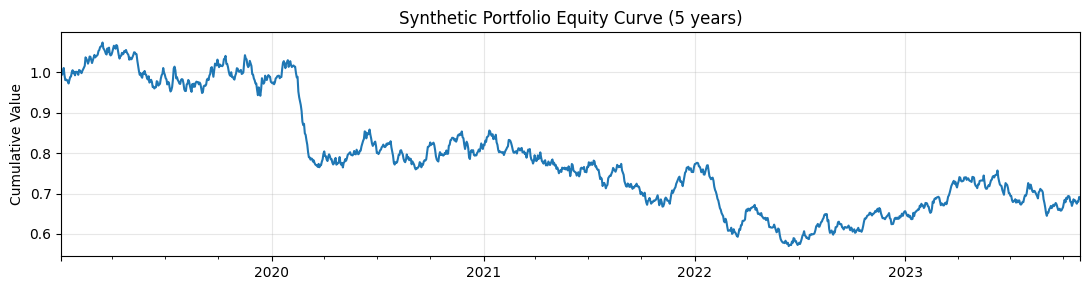

In [3]:
rng = np.random.default_rng(42)
N = 1260  # ~5 years of daily data

dates = pd.date_range("2019-01-02", periods=N, freq="B")

# Portfolio: slight positive drift, ~15% annual vol, two drawdown episodes
daily_vol = 0.15 / np.sqrt(252)
daily_drift = 0.10 / 252

base_returns = rng.normal(daily_drift, daily_vol, N)
# COVID-like crash over ~25 days (rows 290-314): total ~-32%
base_returns[290:315] -= 0.013
# 2022-like drawdown over ~20 days (rows 800-819): total ~-18%
base_returns[800:820] -= 0.009

returns = pd.Series(base_returns, index=dates, name="portfolio")
equity_curve = (1 + returns).cumprod()

# Multi-asset returns (for risk contribution & rolling correlation)
n_assets = 4
asset_names = ["US_Equity", "Intl_Equity", "Bonds", "Gold"]
corr_matrix = np.array([
    [1.0,  0.75, -0.20,  0.10],
    [0.75, 1.0,  -0.15,  0.05],
    [-0.20,-0.15,  1.0,  0.15],
    [0.10,  0.05,  0.15, 1.0],
])
vols = np.array([0.18, 0.22, 0.06, 0.15]) / np.sqrt(252)
L = np.linalg.cholesky(corr_matrix)
raw = rng.standard_normal((N, n_assets))
correlated = (raw @ L.T) * vols
multi_returns = pd.DataFrame(correlated, index=dates, columns=asset_names)
weights = pd.Series({"US_Equity": 0.45, "Intl_Equity": 0.20, "Bonds": 0.25, "Gold": 0.10})

print(f"Portfolio returns: {len(returns)} trading days")
print(f"Equity curve range: {equity_curve.min():.3f} → {equity_curve.max():.3f}")
equity_curve.plot(title="Synthetic Portfolio Equity Curve (5 years)", figsize=(11, 3))
plt.ylabel("Cumulative Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Return Metrics

$$\text{Sharpe} = \frac{\mu - r_f}{\sigma}, \quad \text{Sortino} = \frac{\mu - r_f}{\sigma_{\text{down}}}$$

`compute_metrics` returns annualised return, volatility, Sharpe, Sortino, max drawdown,
and max drawdown duration in a single call.

In [4]:
RISK_FREE_RATE = 0.04  # 4% annual, illustrative

metrics = compute_metrics(
    returns,
    equity_curve=equity_curve,
    risk_free_rate=RISK_FREE_RATE,
    periods_per_year=252,
)

# Add Calmar ratio manually
dd_analysis = compute_drawdowns(equity_curve)
calmar = dd_analysis.calmar_ratio

summary = pd.DataFrame(
    {
        "Value": {
            "Ann. Return": f"{metrics['ann_return']:.2%}",
            "Ann. Volatility": f"{metrics['ann_volatility']:.2%}",
            "Sharpe Ratio": f"{metrics['sharpe']:.2f}",
            "Sortino Ratio": f"{metrics['sortino']:.2f}",
            "Calmar Ratio": f"{calmar:.2f}" if calmar else "N/A",
            "Max Drawdown": f"{metrics['max_dd']:.2%}",
            "Max DD Duration (days)": str(metrics["max_dd_duration_days"]),
        }
    }
)
summary

,Value
Ann. Return,-7.19%
Ann. Volatility,15.14%
Sharpe Ratio,-0.68
Sortino Ratio,-1.08
Calmar Ratio,-0.15
Max Drawdown,-46.92%
Max DD Duration (days),1691


## 4. Drawdown Analysis

$$DD_t = \frac{V_t - \max_{s \leq t} V_s}{\max_{s \leq t} V_s}$$

The underwater chart shows portfolio loss from the last peak at each point in time.

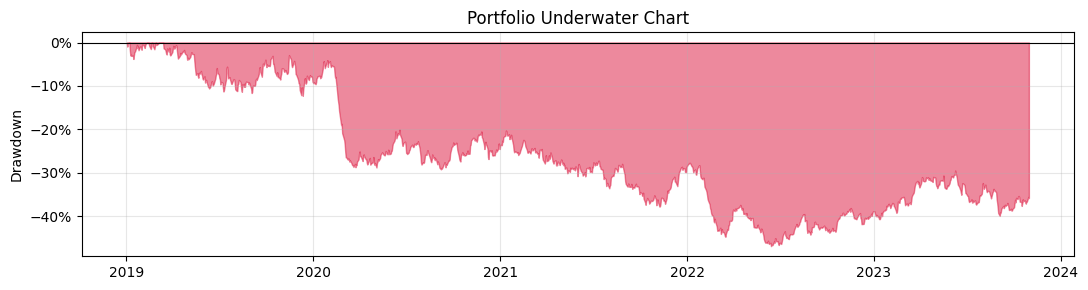


Total drawdown episodes: 6


,peak_date,trough_date,recovery_date,max_drawdown,duration_days,recovery_days
5,2019-03-14,2022-06-14,NaT,-46.92%,1188,NaN
1,2019-01-07,2019-01-15,2019-02-11,-3.79%,8,27.0
3,2019-02-20,2019-02-25,2019-02-28,-1.55%,5,3.0
2,2019-02-13,2019-02-18,2019-02-20,-1.51%,5,2.0
0,2019-01-02,2019-01-03,2019-01-07,-0.94%,1,4.0


In [5]:
# Underwater (drawdown) chart
fig, ax = plt.subplots(figsize=(11, 3))
ax.fill_between(
    dd_analysis.underwater.index,
    dd_analysis.underwater.values,
    0,
    color="crimson",
    alpha=0.5,
    label="Drawdown",
)
ax.set_title("Portfolio Underwater Chart")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.axhline(0, color="black", linewidth=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Episode table — top 5 by depth
ep_df = episodes_to_dataframe(dd_analysis)
ep_df_sorted = ep_df.sort_values("max_drawdown").head(5).copy()
ep_df_sorted["max_drawdown"] = ep_df_sorted["max_drawdown"].map("{:.2%}".format)
print(f"\nTotal drawdown episodes: {len(dd_analysis.episodes)}")
ep_df_sorted

## 5. VaR and CVaR

Compare three estimation methods at the 95% and 99% confidence levels.

| Method | Assumption |
|---|---|
| Historical | Non-parametric; uses empirical return distribution |
| Parametric (Normal) | Returns are normally distributed |
| Parametric (Student-t) | Returns follow a fat-tailed t-distribution (MLE fit) |

In [6]:
# Compare all three methods at 95% and 99%
summary_95 = var_summary(returns, confidence=0.95)
summary_99 = var_summary(returns, confidence=0.99)

combined = pd.concat(
    [summary_95.add_suffix("_95"), summary_99.add_suffix("_99")], axis=1
)
combined = combined.map(lambda x: f"{x:.4%}")
combined.columns = ["VaR (95%)", "CVaR (95%)", "VaR (99%)", "CVaR (99%)"]
print("Daily VaR and CVaR by method:")
combined

Daily VaR and CVaR by method:


,VaR (95%),CVaR (95%),VaR (99%),CVaR (99%)
method,,,,
historical,1.5770%,2.0293%,2.2386%,2.6651%
parametric_normal,1.5933%,1.9917%,2.2431%,2.5662%
parametric_t,1.5887%,2.0079%,2.2699%,2.6259%


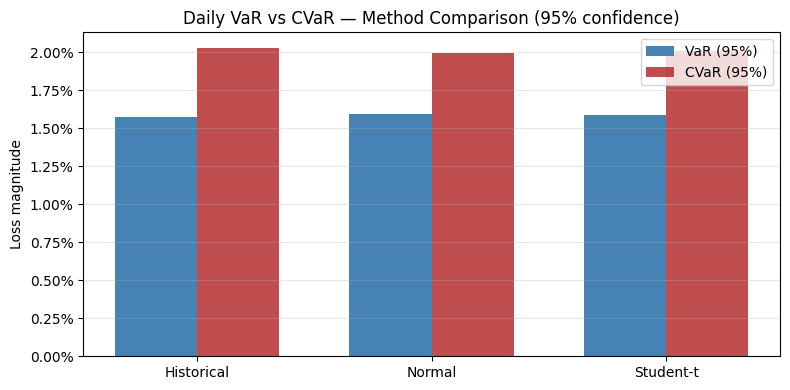

In [7]:
# Bar chart comparison: VaR vs CVaR across methods (95%)
methods = ["historical", "parametric_normal", "parametric_t"]
var_vals  = [var_historical(returns, 0.95).var,
             var_parametric_normal(returns, 0.95).var,
             var_parametric_t(returns, 0.95).var]
cvar_vals = [var_historical(returns, 0.95).cvar,
             var_parametric_normal(returns, 0.95).cvar,
             var_parametric_t(returns, 0.95).cvar]

x = np.arange(len(methods))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width / 2, var_vals,  width, label="VaR (95%)",  color="steelblue")
ax.bar(x + width / 2, cvar_vals, width, label="CVaR (95%)", color="firebrick", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(["Historical", "Normal", "Student-t"])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=2))
ax.set_title("Daily VaR vs CVaR — Method Comparison (95% confidence)")
ax.set_ylabel("Loss magnitude")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Stress Testing

Apply pre-built historical shock scenarios to the portfolio.  
Each scenario shocks a set of asset categories; assets are mapped from portfolio labels
to scenario labels via `asset_map`.

In [8]:
# Map our synthetic asset labels to scenario category labels
asset_map = {
    "US_Equity":    "equities",
    "Intl_Equity":  "equities",
    "Bonds":        "bonds",
    "Gold":         "gold",
}

stress_df = run_stress_test(
    weights,
    scenarios=HISTORICAL_SCENARIOS,
    asset_map=asset_map,
)

# Format as percentages for display
display_df = stress_df.copy()
display_df = display_df.map(lambda x: f"{x:.1%}" if pd.notnull(x) else "")
print("Scenario P&L by asset and portfolio:")
display_df

Scenario P&L by asset and portfolio:


,portfolio_return,US_Equity,Intl_Equity,Bonds,Gold
scenario,,,,,
GFC 2008,-29.5%,-50.0%,-50.0%,10.0%,5.0%
COVID Crash 2020,-21.3%,-34.0%,-34.0%,4.0%,-2.0%
Rate Spike 2022,-21.0%,-25.0%,-25.0%,-18.0%,-2.0%
Dot-com Crash 2000–2002,-27.8%,-49.0%,-49.0%,12.0%,10.0%


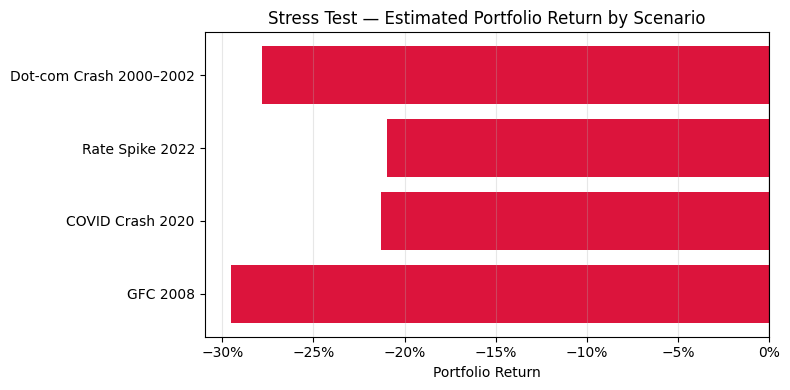

In [9]:
# Portfolio P&L bar chart across scenarios
port_returns_stress = stress_df["portfolio_return"]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["crimson" if v < 0 else "steelblue" for v in port_returns_stress]
ax.barh(port_returns_stress.index, port_returns_stress.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title("Stress Test — Estimated Portfolio Return by Scenario")
ax.set_xlabel("Portfolio Return")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Risk Contribution

Decompose portfolio volatility into per-asset components using the Euler theorem:

$$\text{CRC}_i = w_i \cdot \frac{\partial \sigma_p}{\partial w_i} = w_i \cdot \frac{(\Sigma w)_i}{\sigma_p}$$

The sum of all $\text{CRC}_i$ equals the portfolio volatility $\sigma_p$.

In [10]:
rc = risk_contribution_from_returns(weights, multi_returns, periods_per_year=252)

print(f"Portfolio volatility (annualised): {rc.total_risk:.2%}")
print(f"Diversification ratio            : {rc.diversification_ratio:.2f}x\n")

rc_table = pd.DataFrame({
    "Weight": weights,
    "Marginal RC": rc.marginal_contribution,
    "Component RC": rc.component_contribution,
    "% of Risk": rc.percent_contribution,
})
rc_table["Weight"] = rc_table["Weight"].map("{:.0%}".format)
rc_table["Marginal RC"] = rc_table["Marginal RC"].map("{:.4f}".format)
rc_table["Component RC"] = rc_table["Component RC"].map("{:.4f}".format)
rc_table["% of Risk"] = rc_table["% of Risk"].map("{:.1%}".format)
rc_table

Portfolio volatility (annualised): 11.62%
Diversification ratio            : 1.33x



,Weight,Marginal RC,Component RC,% of Risk
US_Equity,45%,0.1677,0.0754,65.0%
Intl_Equity,20%,0.1905,0.0381,32.8%
Bonds,25%,-0.0037,-0.0009,-0.8%
Gold,10%,0.0352,0.0035,3.0%


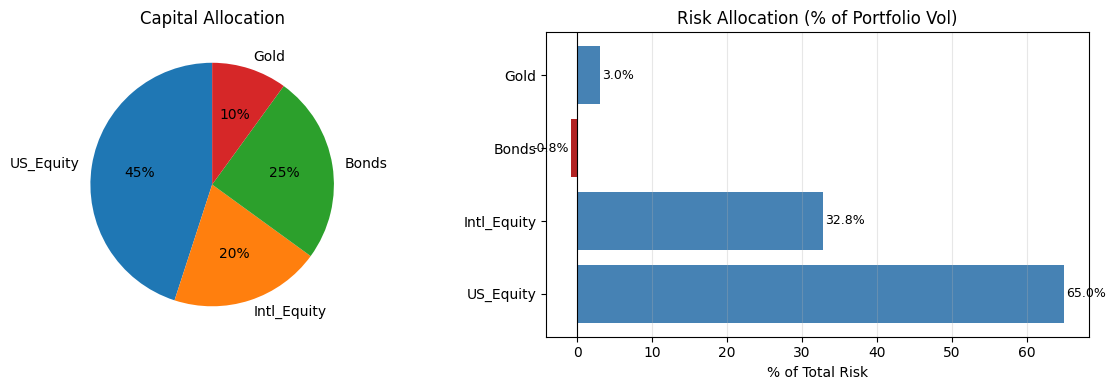

In [12]:
# Capital allocation pie + risk allocation bar (bar handles negative CRC)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Capital allocation pie
axes[0].pie(weights.values, labels=weights.index, autopct="%1.0f%%", startangle=90)
axes[0].set_title("Capital Allocation")

# Right: Risk allocation bar (supports negative contributions from hedging assets)
pct = rc.percent_contribution * 100
colors = ["steelblue" if v >= 0 else "firebrick" for v in pct]
axes[1].barh(pct.index, pct.values, color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Risk Allocation (% of Portfolio Vol)")
axes[1].set_xlabel("% of Total Risk")
axes[1].grid(True, axis="x", alpha=0.3)
for i, (val, label) in enumerate(zip(pct.values, pct.index)):
    axes[1].text(val + (0.3 if val >= 0 else -0.3), i, f"{val:.1f}%",
                 va="center", ha="left" if val >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()

## 8. Rolling Performance Metrics

Rolling windows reveal regime changes that static metrics miss.  
Default window: **63 trading days ≈ 1 quarter**.

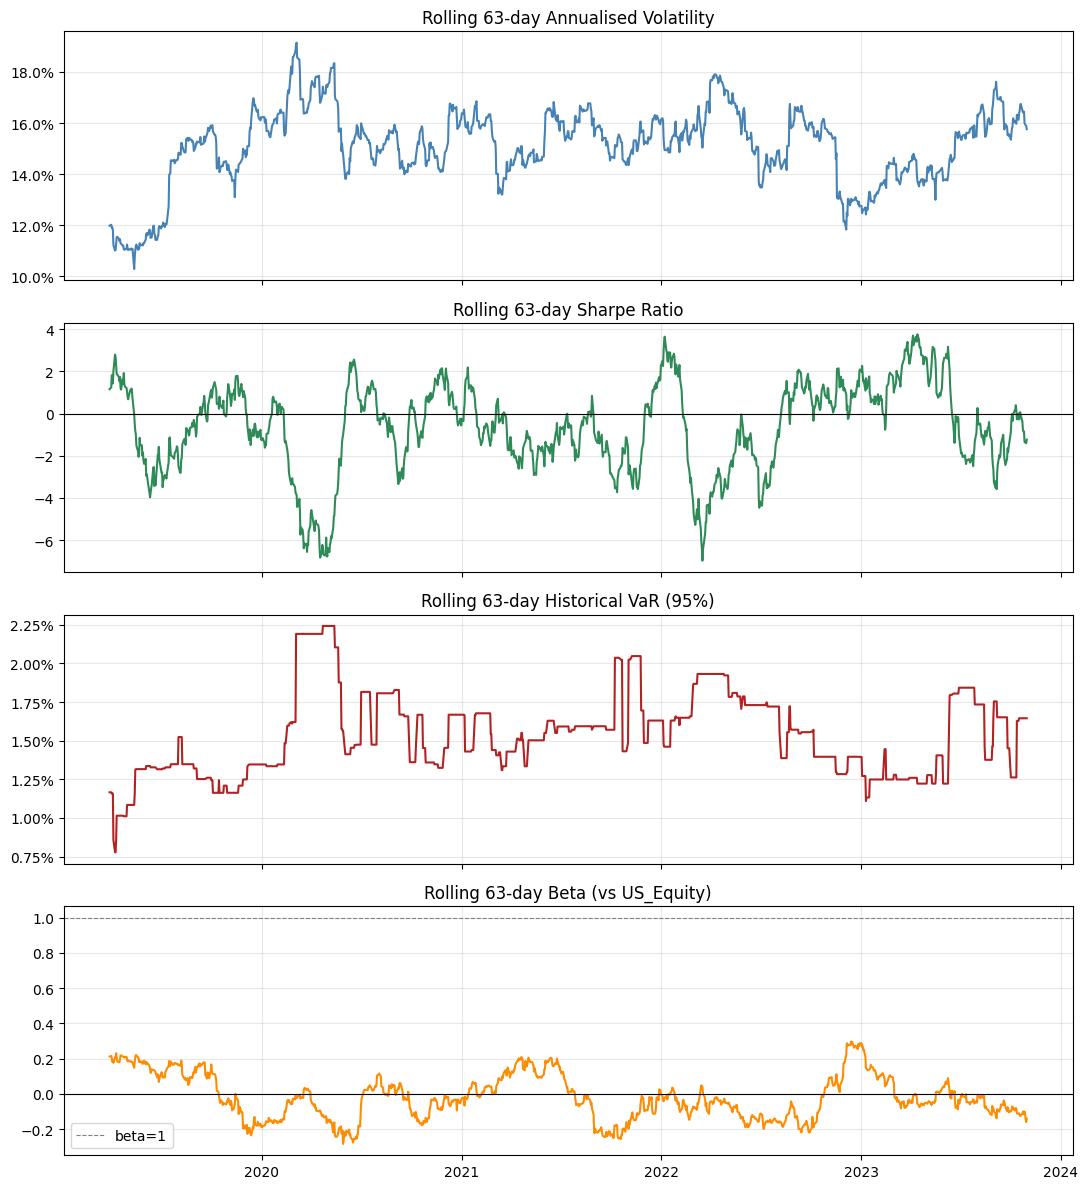

In [13]:
WINDOW = 63  # ~1 quarter

roll_vol    = rolling_volatility(returns, window=WINDOW)
roll_sharpe_q  = rolling_sharpe(returns, window=WINDOW, risk_free_rate=RISK_FREE_RATE)
roll_var_95 = rolling_var(returns, window=WINDOW, confidence=0.95)

# Benchmark proxy: pure equity (first column of multi_returns)
benchmark_ret = multi_returns["US_Equity"]
roll_beta_vals = rolling_beta(returns, benchmark_ret, window=WINDOW)

fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)

axes[0].plot(roll_vol.index, roll_vol.values, color="steelblue")
axes[0].set_title(f"Rolling {WINDOW}-day Annualised Volatility")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].grid(True, alpha=0.3)

axes[1].plot(roll_sharpe_q.index, roll_sharpe_q.values, color="seagreen")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title(f"Rolling {WINDOW}-day Sharpe Ratio")
axes[1].grid(True, alpha=0.3)

axes[2].plot(roll_var_95.index, roll_var_95.values, color="firebrick")
axes[2].set_title(f"Rolling {WINDOW}-day Historical VaR (95%)")
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[2].grid(True, alpha=0.3)

axes[3].plot(roll_beta_vals.index, roll_beta_vals.values, color="darkorange")
axes[3].axhline(1, color="grey", linewidth=0.8, linestyle="--", label="beta=1")
axes[3].axhline(0, color="black", linewidth=0.8)
axes[3].set_title(f"Rolling {WINDOW}-day Beta (vs US_Equity)")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

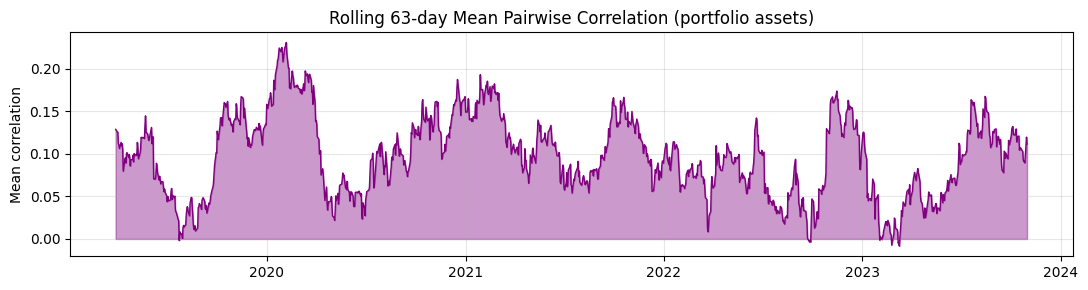

In [14]:
# Rolling mean pairwise correlation — portfolio diversification over time
roll_corr = rolling_mean_correlation(multi_returns, window=WINDOW)

fig, ax = plt.subplots(figsize=(11, 3))
ax.fill_between(roll_corr.index, roll_corr.values, alpha=0.4, color="purple")
ax.plot(roll_corr.index, roll_corr.values, color="purple", linewidth=1)
ax.set_title(f"Rolling {WINDOW}-day Mean Pairwise Correlation (portfolio assets)")
ax.set_ylabel("Mean correlation")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Factor Attribution (Fama-French OLS)

Regress portfolio **excess returns** on the FF3 factors to decompose performance into:

- $\alpha$ — skill / unexplained return  
- $\beta_{Mkt-RF}$ — market exposure  
- $\beta_{SMB}$ — small-cap tilt  
- $\beta_{HML}$ — value tilt  

$$r_p - r_f = \alpha + \beta_{Mkt} (r_m - r_f) + \beta_{SMB} \cdot SMB + \beta_{HML} \cdot HML + \varepsilon$$

We use synthetic factor data aligned to our return period (no network call needed).

In [15]:
from scipy import stats

# Synthetic FF3-like factors aligned to our return dates
ff_rng = np.random.default_rng(7)
ff_corr = np.array([[1.0, 0.1, -0.2], [0.1, 1.0, 0.05], [-0.2, 0.05, 1.0]])
ff_L = np.linalg.cholesky(ff_corr)
ff_vols = np.array([0.20, 0.10, 0.10]) / np.sqrt(252)
ff_raw = ff_rng.standard_normal((N, 3)) @ ff_L.T * ff_vols
ff3_synth = pd.DataFrame(ff_raw, index=dates, columns=["Mkt-RF", "SMB", "HML"])
rf_daily = RISK_FREE_RATE / 252

# Compute excess returns
excess_returns = returns - rf_daily
# Align
df_reg = pd.concat([excess_returns.rename("excess_port"), ff3_synth], axis=1).dropna()

# OLS using numpy lstsq
X = df_reg[["Mkt-RF", "SMB", "HML"]].values
y = df_reg["excess_port"].values
X_with_const = np.hstack([np.ones((len(X), 1)), X])
beta, _, _, _ = np.linalg.lstsq(X_with_const, y, rcond=None)

# Compute t-stats and R²
y_hat = X_with_const @ beta
ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r_squared = 1 - ss_res / ss_tot
n, k = len(y), X_with_const.shape[1]
mse = ss_res / (n - k)
cov_beta = mse * np.linalg.inv(X_with_const.T @ X_with_const)
se = np.sqrt(np.diag(cov_beta))
t_stats = beta / se
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - k))

factor_names = ["alpha", "Mkt-RF", "SMB", "HML"]
attribution = pd.DataFrame({
    "Coefficient": beta,
    "Std Error": se,
    "t-stat": t_stats,
    "p-value": p_values,
}, index=factor_names)
attribution["Annualised alpha"] = [beta[0] * 252] + [None] * 3

print(f"R²: {r_squared:.4f}   Adj-R²: {1 - (1 - r_squared)*(n-1)/(n-k):.4f}\n")
attribution.round(4)

R²: 0.0025   Adj-R²: 0.0001



,Coefficient,Std Error,t-stat,p-value,Annualised alpha
alpha,-0.0004,0.0003,-1.6280,0.1038,-0.1104
Mkt-RF,-0.0328,0.0218,-1.5022,0.1333,NaN
SMB,-0.0244,0.0440,-0.5560,0.5783,NaN
HML,0.0113,0.0440,0.2581,0.7964,NaN


## 10. Tear Sheet Summary

Consolidate all computed metrics into a single styled tear sheet.

$$IR = \frac{\overline{r_p - r_b}}{\sigma_{r_p - r_b}}$$

In [16]:
# Benchmark: US_Equity proxy from multi_returns
benchmark_equity = multi_returns["US_Equity"]
tracking_error = (returns - benchmark_equity).std() * np.sqrt(252)
active_return = (returns - benchmark_equity).mean() * 252
info_ratio = active_return / tracking_error if tracking_error > 0 else float("nan")

var_95 = var_historical(returns, confidence=0.95)
var_99 = var_historical(returns, confidence=0.99)

tear_sheet = pd.DataFrame(
    {
        "Metric": [
            "Period",
            "Trading Days",
            "Annualised Return",
            "Annualised Volatility",
            "Sharpe Ratio",
            "Sortino Ratio",
            "Calmar Ratio",
            "Max Drawdown",
            "Max DD Duration (days)",
            "Number of Drawdown Episodes",
            "Diversification Ratio",
            "Historical VaR (daily, 95%)",
            "Historical CVaR (daily, 95%)",
            "Historical VaR (daily, 99%)",
            "Historical CVaR (daily, 99%)",
            "Tracking Error (vs US_Equity)",
            "Information Ratio",
            "FF3 Alpha (annualised)",
            "FF3 R²",
        ],
        "Value": [
            f"{returns.index[0].date()} → {returns.index[-1].date()}",
            str(len(returns)),
            f"{metrics['ann_return']:.2%}",
            f"{metrics['ann_volatility']:.2%}",
            f"{metrics['sharpe']:.2f}",
            f"{metrics['sortino']:.2f}",
            f"{calmar:.2f}" if calmar else "N/A",
            f"{metrics['max_dd']:.2%}",
            str(metrics["max_dd_duration_days"]),
            str(len(dd_analysis.episodes)),
            f"{rc.diversification_ratio:.2f}x",
            f"{var_95.var:.4%}",
            f"{var_95.cvar:.4%}",
            f"{var_99.var:.4%}",
            f"{var_99.cvar:.4%}",
            f"{tracking_error:.2%}",
            f"{info_ratio:.2f}",
            f"{beta[0] * 252:.4%}",
            f"{r_squared:.4f}",
        ],
    }
).set_index("Metric")

tear_sheet

,Value
Metric,
Period,2019-01-02 → 2023-10-31
Trading Days,1260
Annualised Return,-7.19%
Annualised Volatility,15.14%
Sharpe Ratio,-0.68
Sortino Ratio,-1.08
Calmar Ratio,-0.15
Max Drawdown,-46.92%
Max DD Duration (days),1691


In [17]:
# Save tear sheet to HTML
output_path = repo_root / "examples" / "notebooks" / "tear_sheet.html"
html = tear_sheet.to_html(classes="tear-sheet")
output_path.write_text(html)
print(f"Tear sheet saved to: {output_path}")

# Reminder: tear_sheet.html is NOT sensitive but also NOT required to be committed.
# Add it to .gitignore if you prefer not to track generated artefacts.

Tear sheet saved to: /Users/jiahuiwu/projects/quant-trading/examples/notebooks/tear_sheet.html


---

## Summary

| Phase 5 Module | What it provides |
|---|---|
| `risk/var.py` | Historical, parametric normal & t VaR/CVaR |
| `risk/stress.py` | Pre-built + custom shock scenarios |
| `risk/contribution.py` | Euler risk decomposition, component VaR |
| `risk/drawdown.py` | Underwater chart, episode table, Calmar |
| `risk/rolling.py` | Rolling vol, Sharpe, Sortino, beta, VaR, correlation |

**Next:** See `example_backtest.ipynb` to run a real strategy and feed actual returns
into this risk pipeline.